# Regression Logistic Student Exam Performance Prediction Homework

In [25]:
%matplotlib inline
import warnings
import os
from pathlib import Path

import pandas as pd

import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
BASE_DIR = Path.cwd()

In [30]:
try:
    import kagglehub
    path = kagglehub.dataset_download("mrsimple07/student-exam-performance-prediction")
    filepath = os.path.join(path, "student_exam_data.csv")
    if not os.path.exists(filepath):
        print("Dataset not found. Please check the Kaggle dataset path.")
        raise FileNotFoundError(f"Dataset not found at {filepath}")
except (ImportError, FileNotFoundError):
    filepath = BASE_DIR / "dataset" / "student_exam_data.csv"


target = "Pass/Fail"
df = pd.read_csv(filepath)
df.head()

X = df.drop(columns=[target]).values
y = df[target].values
print(df.columns)

Index(['Study Hours', 'Previous Exam Score', 'Pass/Fail'], dtype='str')


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Normalização dos dados

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertendo para tensores do PyTorch

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

print("X_train_tensor shape:", X_train.shape)
print("y_train_tensor shape:", y_train.shape)
print("X_val_tensor shape:", X_test.shape)
print("y_val_tensor shape:", y_test.shape)

X_train_tensor shape: torch.Size([400, 2])
y_train_tensor shape: torch.Size([400])
X_val_tensor shape: torch.Size([100, 2])
y_val_tensor shape: torch.Size([100])


In [41]:
model = torch.nn.Linear(in_features=X_train.shape[1], out_features=2)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

In [42]:
epochs = 100
losses = []
accuracies = []

for epoch in range(epochs):
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _,predicts = torch.max(outputs, 1)

    accuracy = (predicts == y_train).float().mean()
    accuracies.append(accuracy.item())
    if (epoch + 1) % 10 == 0:
        print(
            f'Epoch [{epoch+1}/{epochs}], '
            f'Loss: {loss.item():.4f}, '
            f'Acc: {accuracy.item():.4f}'
        )

Epoch [10/100], Loss: 0.6477, Acc: 0.5925
Epoch [20/100], Loss: 0.6243, Acc: 0.5875
Epoch [30/100], Loss: 0.6027, Acc: 0.5925
Epoch [40/100], Loss: 0.5825, Acc: 0.5925
Epoch [50/100], Loss: 0.5639, Acc: 0.6100
Epoch [60/100], Loss: 0.5467, Acc: 0.6375
Epoch [70/100], Loss: 0.5307, Acc: 0.6575
Epoch [80/100], Loss: 0.5160, Acc: 0.6800
Epoch [90/100], Loss: 0.5024, Acc: 0.6950
Epoch [100/100], Loss: 0.4898, Acc: 0.7150


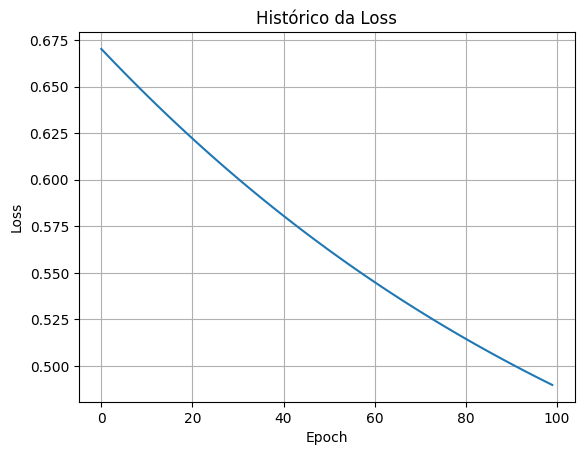

In [43]:
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Histórico da Loss")
plt.grid(True)
plt.show()

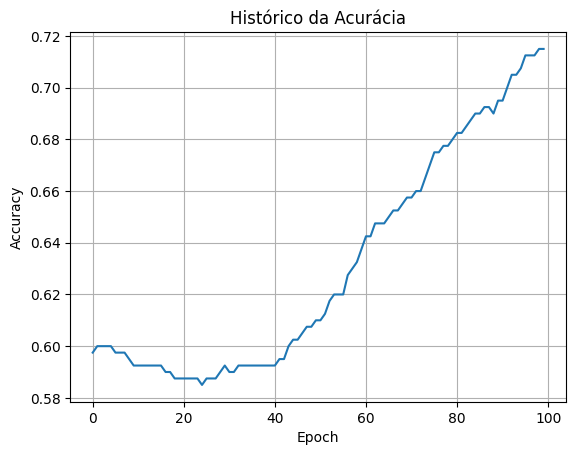

In [44]:
plt.plot(accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Histórico da Acurácia")
plt.grid(True)
plt.show()